# KSB — Per-input kinematics and gap curves

Plots position, velocity, acceleration, jerk, and g_i(t) for each input.
The gap window replicates exactly the `[t_window_start, t_window_end]` logic
used inside `KSBSimulation.run()` / `compute_pairs()`.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from ksb.simulation.ksb_simulation import KSBSimulation
from ksb.simulation.result import SimulationResult
from ksb.planning.solvers.scurve import SCurveSolver
from ksb.planning.solvers.quintic import QuinticSolver
from ksb.visualization.input_plots import InputPlotter

import yaml
from pathlib import Path
with open(Path('..') / 'configs' / 'system' / 'default.yaml') as f:
    cfg = yaml.safe_load(f)

cfg

{'batch': 100,
 'input_length': 0.32,
 'input_gap_mean': 0.6,
 'input_gap_std': 0.05,
 'arrival_rate_ppm': 150,
 'upstream_control': 'acc',
 'L_upstream': 3.0,
 'j_u_max': 100.0,
 'v_u_max': 3.5,
 'a_u_max': 0.05,
 'jmax': 100.0,
 'Vmax': 3.5,
 'Amax': 8.5,
 'beta': 0.1,
 'gamma': 0,
 'solver': 'ruckig',
 'L_buffer': 3,
 'n_buffer_seg': 8,
 'eta_v': 1.8,
 'v_min': 0.0,
 'start_margin': 1,
 'end_margin': 0.0,
 'L_registrar': 1.0,
 'n_reg_seg': 1,
 'L_downstream': 2.0,
 'eta_s': 1.5,
 'eta_r': 1.1,
 'a_max_sync': 25.0,
 'j_max_sync': 300}

In [2]:
# ── Run simulation and display ────────────────────────────────────────────────
sim: KSBSimulation = KSBSimulation(cfg=cfg)
result: SimulationResult = sim.run(seed=42, skip_pair_records = False)
print(result.skip_indices)

[ 3 22 26 30 45 49 65 69]


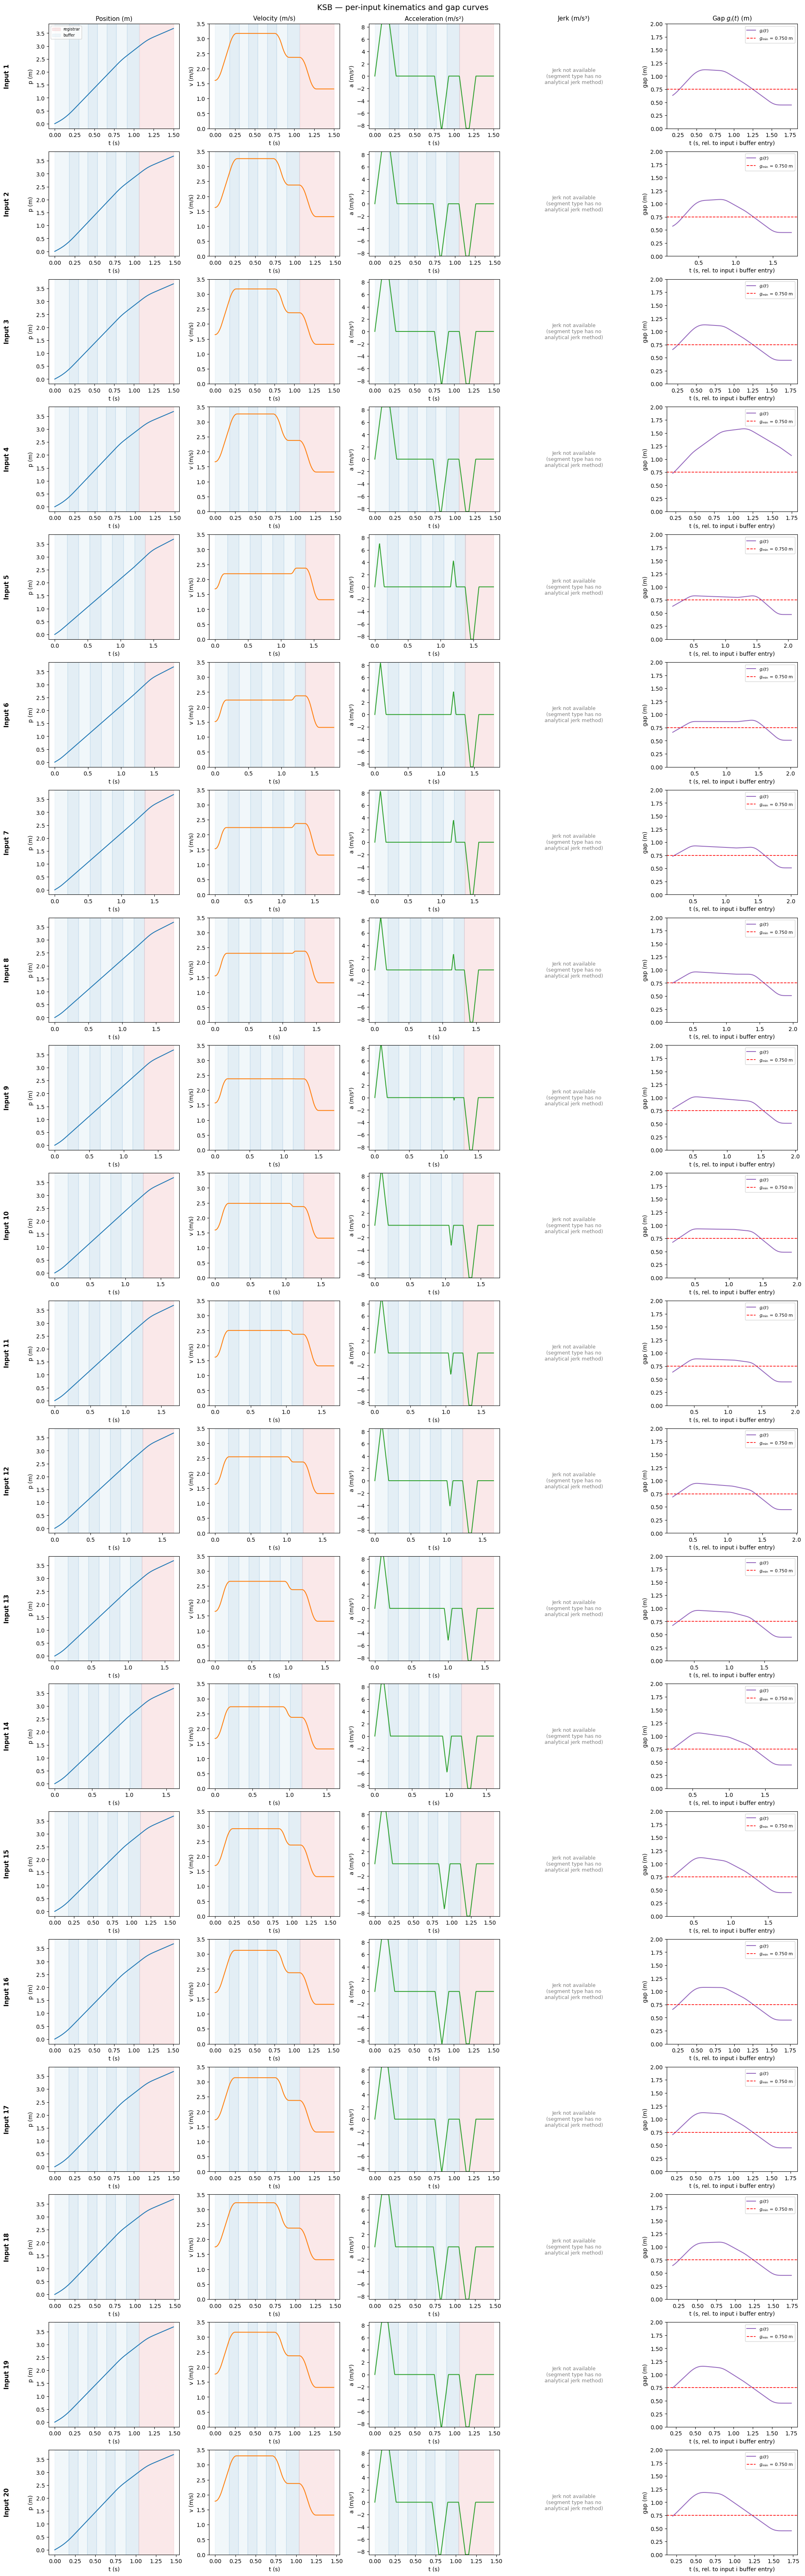

In [3]:
plotter = InputPlotter(cfg)
fig = plotter.plot(result, N=20, i_start=00)